In [ ]:
import torch
print(torch.cuda.is_available())       # Debe decir True
print(torch.cuda.get_device_name(0))   # Debe decir Tesla T4

True
Tesla T4


Instalar librerias

In [ ]:
!pip install transformers datasets scikit-learn

Montar Drive

In [ ]:
from google.drive import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.drive'

In [ ]:
'/content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/Big_AHR.csv'

In [ ]:
import random, os
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Semilla fija : {SEED}")
print(f"Dispositivo  : {DEVICE}")
print(f"PyTorch      : {torch.__version__}")

Semilla fija : 42
Dispositivo  : cuda
PyTorch      : 2.10.0+cu128


In [ ]:
!pip install -q transformers accelerate datasets scikit-learn seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pathlib

DATA_PATH   = pathlib.Path('/content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/Big_AHR.csv')
RESULTS_DIR = pathlib.Path('/content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/results')
FIGURES_DIR = pathlib.Path('/content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset : {DATA_PATH}")
print(f"Existe  : {DATA_PATH.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset : /content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/Big_AHR.csv
Existe  : True


In [ ]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print(f"Shape       : {df.shape}")
print(f"Columnas    : {list(df.columns)}")
print(f"\nDistribución de clases (rating):")
print(df['rating'].value_counts().sort_index())
print(f"\nNulos en review_text : {df['review_text'].isna().sum()}")
print(f"Nulos en rating      : {df['rating'].isna().sum()}")

df.head(3)

Shape       : (18172, 7)
Columnas    : ['Unnamed: 0', 'title', 'rating', 'review_text', 'location', 'hotel', 'label']

Distribución de clases (rating):
rating
1    1677
2     994
3    2274
4    4222
5    9005
Name: count, dtype: int64

Nulos en review_text : 0
Nulos en rating      : 0


,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1


In [ ]:
# Quedarse solo con lo necesario y convertir rating a índice 0-4
df_clean = df[['review_text', 'rating']].copy()

# BETO necesita strings limpios, no nulos
df_clean['review_text'] = df_clean['review_text'].astype(str).str.strip()

# Convertir rating 1-5 → label 0-4 (PyTorch necesita índices desde 0)
df_clean['label'] = df_clean['rating'] - 1

print("Distribución final de etiquetas (0-4):")
print(df_clean['label'].value_counts().sort_index())
print(f"\nEjemplo de texto:")
print(df_clean['review_text'].iloc[0][:200])

Distribución final de etiquetas (0-4):
label
0    1677
1     994
2    2274
3    4222
4    9005
Name: count, dtype: int64

Ejemplo de texto:
Un hotel muy bueno.  El personal fue muy amable y profesional. Nos gustaban desayuno mucho también. El habitación cómoda y limpia. Volvimos a próxima vez en Seville por seguro. Lo recomiendo !! Y tamb


In [ ]:
from sklearn.model_selection import train_test_split

# Split train / temp
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=SEED,
    stratify=df_clean['label']
)

# Split val / test del temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print(f"Train : {len(train_df):>5} muestras")
print(f"Val   : {len(val_df):>5} muestras")
print(f"Test  : {len(test_df):>5} muestras")
print(f"Total : {len(train_df)+len(val_df)+len(test_df):>5} muestras")

Train : 12720 muestras
Val   :  2726 muestras
Test  :  2726 muestras
Total : 18172 muestras


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Verificar con un ejemplo real del dataset
ejemplo = df_clean['review_text'].iloc[0]
tokens  = tokenizer(ejemplo, truncation=True, max_length=128, padding='max_length')

print(f"Modelo        : {MODEL_NAME}")
print(f"Vocab size    : {tokenizer.vocab_size}")
print(f"Input IDs     : {tokens['input_ids'][:10]} ...")
print(f"Attention mask: {tokens['attention_mask'][:10]} ...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Modelo        : dccuchile/bert-base-spanish-wwm-cased
Vocab size    : 31002
Input IDs     : [4, 1246, 5225, 1456, 2536, 1009, 1162, 2387, 1341, 1456] ...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...


In [ ]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN    = 128   # BETO acepta hasta 512, pero 128 cubre bien reseñas cortas y es más rápido
BATCH_SIZE = 32

class HotelReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Crear datasets
train_dataset = HotelReviewDataset(train_df['review_text'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = HotelReviewDataset(val_df['review_text'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = HotelReviewDataset(test_df['review_text'],  test_df['label'],  tokenizer, MAX_LEN)

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"MAX_LEN       : {MAX_LEN}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Batches train : {len(train_loader)}")
print(f"Batches val   : {len(val_loader)}")
print(f"Batches test  : {len(test_loader)}")

MAX_LEN       : 128
Batch size    : 32
Batches train : 398
Batches val   : 86
Batches test  : 86


In [ ]:
from transformers import AutoModelForSequenceClassification

NUM_CLASSES = 5

# Cargar BETO con cabeza de clasificación
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

# ── Fine-Tuning: congelar todo excepto el último bloque del encoder + clasificador ──
# BETO tiene 12 capas (encoder.layer.0 ... encoder.layer.11)
# Congelamos todas menos la última (layer.11)

for name, param in model.named_parameters():
    param.requires_grad = False  # Congelar todo primero

for name, param in model.named_parameters():
    if any(layer in name for layer in ['encoder.layer.11', 'pooler', 'classifier']):
        param.requires_grad = True  # Descongelar última capa + clasificador

# Verificar qué quedó descongelado
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}")
print(f"Porcentaje entrenable  : {100*trainable_params/total_params:.1f}%")
print("\nCapas descongeladas:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  ✓ {name}")

model = model.to(DEVICE)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Parámetros totales     : 109,854,725
Parámetros entrenables : 7,682,309
Porcentaje entrenable  : 7.0%

Capas descongeladas:
  ✓ bert.encoder.layer.11.attention.self.query.weight
  ✓ bert.encoder.layer.11.attention.self.query.bias
  ✓ bert.encoder.layer.11.attention.self.key.weight
  ✓ bert.encoder.layer.11.attention.self.key.bias
  ✓ bert.encoder.layer.11.attention.self.value.weight
  ✓ bert.encoder.layer.11.attention.self.value.bias
  ✓ bert.encoder.layer.11.attention.output.dense.weight
  ✓ bert.encoder.layer.11.attention.output.dense.bias
  ✓ bert.encoder.layer.11.attention.output.LayerNorm.weight
  ✓ bert.encoder.layer.11.attention.output.LayerNorm.bias
  ✓ bert.encoder.layer.11.intermediate.dense.weight
  ✓ bert.encoder.layer.11.intermediate.dense.bias
  ✓ bert.encoder.layer.11.output.dense.weight
  ✓ bert.encoder.layer.11.output.dense.bias
  ✓ bert.encoder.layer.11.output.LayerNorm.weight
  ✓ bert.encoder.layer.11.output.LayerNorm.bias
  ✓ bert.pooler.dense.weight
  ✓ bert.pooler

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from transformers import get_linear_schedule_with_warmup

# Class weights para manejar el desbalance
classes           = np.array([0, 1, 2, 3, 4])
class_weights     = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  Clase {i+1} (rating {i+1}★): {w:.4f}")

# Función de pérdida con class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizador — torch.optim.AdamW (AdamW fue removido de transformers)
LR       = 2e-5
N_EPOCHS = 5

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01
)

# Scheduler con warmup
total_steps  = len(train_loader) * N_EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nLearning rate : {LR}")
print(f"Épocas        : {N_EPOCHS}")
print(f"Total steps   : {total_steps}")
print(f"Warmup steps  : {warmup_steps}")

Class weights:
  Clase 1 (rating 1★): 2.1670
  Clase 2 (rating 2★): 3.6552
  Clase 3 (rating 3★): 1.5980
  Clase 4 (rating 4★): 0.8609
  Clase 5 (rating 5★): 0.4036

Learning rate : 2e-05
Épocas        : 5
Total steps   : 1990
Warmup steps  : 199


In [ ]:
import time
from tqdm import tqdm

CHECKPOINT_PATH = RESULTS_DIR / "beto_best.pt"

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader, desc="  Train", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Val  ", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


# ── Historial para las curvas ──────────────────────────────────────────────
loss_history     = []
val_loss_history = []
acc_history      = []
val_acc_history  = []
best_val_loss    = float('inf')
best_epoch       = 1
start_time       = time.time()

print(f"{'Época':>6} {'Train Loss':>11} {'Val Loss':>10} {'Train Acc':>10} {'Val Acc':>9} {'★':>3}")
print("─" * 58)

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion, DEVICE)

    loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    # Guardar mejor modelo
    improved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        improved = "✓"

    print(f"{epoch:>6} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>10.4f} {val_acc:>9.4f} {improved:>3}")

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed:.0f}s")
print(f"Mejor época : {best_epoch}  (val_loss={best_val_loss:.4f})")
print(f"Checkpoint  : {CHECKPOINT_PATH}")

 Época  Train Loss   Val Loss  Train Acc   Val Acc   ★
──────────────────────────────────────────────────────────


     1      1.3165     1.0369     0.4770    0.6240   ✓


     2      0.9734     0.9871     0.6248    0.6467   ✓


     3      0.9142     0.9515     0.6445    0.6511   ✓


     4      0.8843     0.9409     0.6476    0.6596   ✓


     5      0.8595     0.9396     0.6610    0.6537   ✓

Entrenamiento completado en 684s
Mejor época : 5  (val_loss=0.9396)
Checkpoint  : /content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/results/beto_best.pt


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix

def evaluate_model(model, loader, checkpoint_path, device):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Test"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

y_true, y_pred = evaluate_model(model, test_loader, CHECKPOINT_PATH, DEVICE)

# ── Calcular métricas ──────────────────────────────────────────────────────
accuracy                    = accuracy_score(y_true, y_pred)
precision, recall, f1, _    = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
f1_per_class_arr            = f1_score(y_true, y_pred, average=None, zero_division=0)
cm                          = confusion_matrix(y_true, y_pred).tolist()

CLASS_NAMES  = ["1", "2", "3", "4", "5"]
f1_per_class = {CLASS_NAMES[i]: round(float(v), 6) for i, v in enumerate(f1_per_class_arr)}

print("── Métricas finales (test set) ─────────────────────────")
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Precision macro : {precision:.4f}")
print(f"  Recall macro    : {recall:.4f}")
print(f"  F1 macro        : {f1:.4f}")
print("  F1 por clase:")
for cls, val in f1_per_class.items():
    print(f"    Clase {cls}★ : {val:.4f}")
print("────────────────────────────────────────────────────────")

  Test: 100%|██████████| 86/86 [00:26<00:00,  3.30it/s]

── Métricas finales (test set) ─────────────────────────
  Accuracy        : 0.6592
  Precision macro : 0.5810
  Recall macro    : 0.5983
  F1 macro        : 0.5873
  F1 por clase:
    Clase 1★ : 0.7287
    Clase 2★ : 0.3860
    Clase 3★ : 0.5138
    Clase 4★ : 0.5140
    Clase 5★ : 0.7943
────────────────────────────────────────────────────────


In [ ]:
import json

metrics_dict = {
    "model_name": "beto_finetuned",
    "owner": "Sebastián Ruiz",
    "track": "TI",
    "config": {
        "base_model": MODEL_NAME,
        "layers_unfrozen": ["encoder.layer.11", "pooler", "classifier"],
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": 0.01,
        "use_class_weights": True,
        "n_params": sum(p.numel() for p in model.parameters()),
        "trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    },
    "metrics": {
        "accuracy":         round(float(accuracy), 6),
        "precision_macro":  round(float(precision), 6),
        "recall_macro":     round(float(recall), 6),
        "f1_macro":         round(float(f1), 6),
        "f1_per_class":     f1_per_class,
        "confusion_matrix": cm
    },
    "training": {
        "epochs_run":        N_EPOCHS,
        "best_epoch":        best_epoch,
        "training_time_seconds": int(elapsed),
        "loss_history":      loss_history,
        "val_loss_history":  val_loss_history,
        "acc_history":       acc_history,
        "val_acc_history":   val_acc_history
    }
}

json_path = RESULTS_DIR / "beto_finetuned_metrics.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)

print(f"JSON guardado → {json_path}")

JSON guardado → /content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/results/beto_finetuned_metrics.json


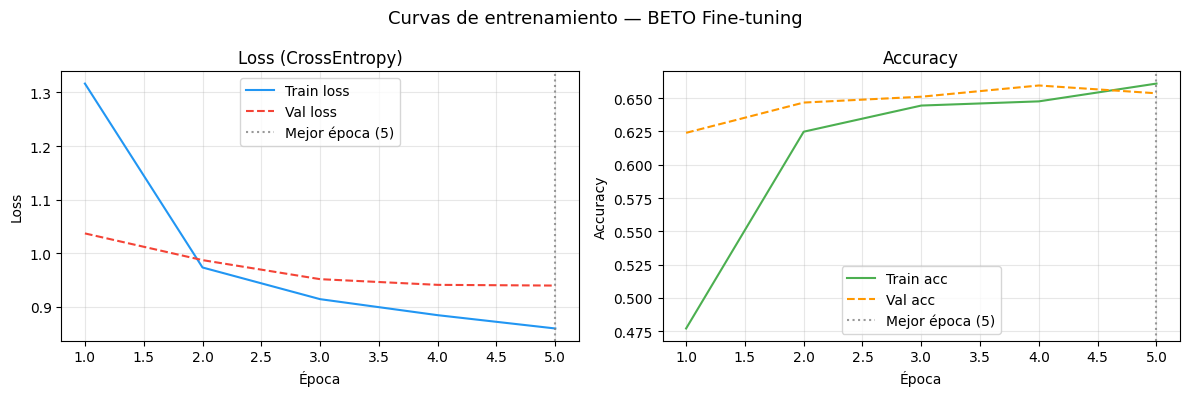

Guardado → /content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/figures/beto_curves.png


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de entrenamiento — BETO Fine-tuning", fontsize=13)

# Loss
ax = axes[0]
ax.plot(epochs, loss_history,     label="Train loss", color="#2196F3")
ax.plot(epochs, val_loss_history, label="Val loss",   color="#F44336", linestyle="--")
ax.axvline(best_epoch, color="gray", linestyle=":", alpha=0.8, label=f"Mejor época ({best_epoch})")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Loss (CrossEntropy)"); ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs, acc_history,     label="Train acc", color="#4CAF50")
ax.plot(epochs, val_acc_history, label="Val acc",   color="#FF9800", linestyle="--")
ax.axvline(best_epoch, color="gray", linestyle=":", alpha=0.8, label=f"Mejor época ({best_epoch})")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = FIGURES_DIR / "beto_curves.png"
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado → {curves_path}")

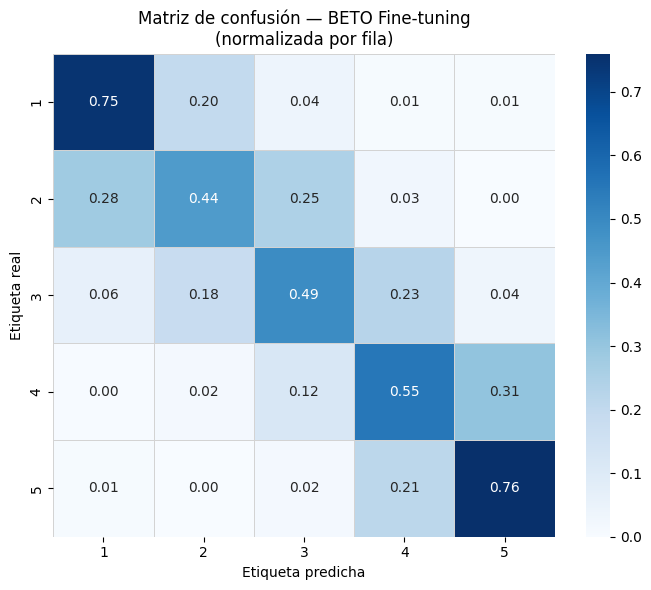

Guardado → /content/drive/MyDrive/Master en IA/Semestre 2/Aprendizaje Profundo/Corte Final/figures/beto_confusion_matrix.png


In [ ]:
import seaborn as sns
import numpy as np

cm_array = np.array(cm)
cm_norm  = cm_array / cm_array.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5, linecolor="lightgray"
)
ax.set_title("Matriz de confusión — BETO Fine-tuning\n(normalizada por fila)", fontsize=12)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.tight_layout()

cm_path = FIGURES_DIR / "beto_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado → {cm_path}")